# Data Augmentation

**Goal**: Implement data augmentation. Starts by looking at the data being loaded by a trained YOLO model. This demonstrates that the model is trained on augmentated data, transformed from the original images. Then, use the Torchvision transforms to generate similar augmentated data.

**Objectives**

- Explore the data loaded for training in the YOLO model.

- Observe augmented training data in YOLO.
 
- Use Torchvision transforms for data augmentation.

- See how bounding boxes need to transform along with images.

- Compose several augmentation techniques together.

**Getting Started**

In [4]:
import pathlib
import sys 

import matplotlib.pyplot as plt 
import torch
import torchinfo
import torchvision
import ultralytics
from PIL import Image
from torchvision.transforms import v2
from ultralytics import YOLO

In [5]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", plt.matplotlib.__version__)
print("PIL version:", Image.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)
print("ultralytics version:", ultralytics.__version__)

Platform: win32
Python version: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
---
matplotlib version: 3.8.3
PIL version: 10.2.0
torch version: 2.5.1+cpu
torchvision version: 0.20.1+cpu
ultralytics version: 8.3.99


The classes of the Dhaka AI data set.

In [6]:
CLASS_DICT = dict(
    enumerate(
        [
            "ambulance",
            "army vehicle",
            "auto rickshaw",
            "bicycle",
            "bus",
            "car",
            "garbagevan",
            "human hauler",
            "minibus",
            "minivan",
            "motorbike",
            "pickup",
            "policecar",
            "rickshaw",
            "scooter",
            "suv",
            "taxi",
            "three wheelers (CNG)",
            "truck",
            "van",
            "wheelbarrow",
        ]
    )
)

print("CLASS_DICT type,", type(CLASS_DICT))
CLASS_DICT

CLASS_DICT type, <class 'dict'>


{0: 'ambulance',
 1: 'army vehicle',
 2: 'auto rickshaw',
 3: 'bicycle',
 4: 'bus',
 5: 'car',
 6: 'garbagevan',
 7: 'human hauler',
 8: 'minibus',
 9: 'minivan',
 10: 'motorbike',
 11: 'pickup',
 12: 'policecar',
 13: 'rickshaw',
 14: 'scooter',
 15: 'suv',
 16: 'taxi',
 17: 'three wheelers (CNG)',
 18: 'truck',
 19: 'van',
 20: 'wheelbarrow'}

**Data Augmentation in Our YOLO Model**

Finding a saved version of the model showing all of the training runs that have been completed.

In [7]:
runs_dir = pathlib.Path("runs", "detect")
list(runs_dir.glob("train*"))

[WindowsPath('runs/detect/train'),
 WindowsPath('runs/detect/train2'),
 WindowsPath('runs/detect/train3'),
 WindowsPath('runs/detect/train4'),
 WindowsPath('runs/detect/train5'),
 WindowsPath('runs/detect/train6')]

 Choose a training run, and check that there are model weights saved in the weights/best.pt file for that run.

In [8]:
run_dir = runs_dir / "train"
weights_file = run_dir / "weights" / "best.pt"

print("Weights file exists?", weights_file.exists())

Weights file exists? True


In [9]:
model = YOLO(weights_file)

torchinfo.summary(model)

Layer (type:depth-idx)                                  Param #
YOLO                                                    --
├─DetectionModel: 1-1                                   --
│    └─Sequential: 2-1                                  --
│    │    └─Conv: 3-1                                   (464)
│    │    └─Conv: 3-2                                   (4,672)
│    │    └─C2f: 3-3                                    (7,360)
│    │    └─Conv: 3-4                                   (18,560)
│    │    └─C2f: 3-5                                    (49,664)
│    │    └─Conv: 3-6                                   (73,984)
│    │    └─C2f: 3-7                                    (197,632)
│    │    └─Conv: 3-8                                   (295,424)
│    │    └─C2f: 3-9                                    (460,288)
│    │    └─SPPF: 3-10                                  (164,608)
│    │    └─Upsample: 3-11                              --
│    │    └─Concat: 3-12                           

Run on one epoch.

In [ ]:
result = model.train(
    data=model.overrides["data"],
    epochs=1,
    batch=8,
    workers=1,
)

In [ ]:
loader = model.trainer.train_loader

print(type(loader))

Load one batch from loader into the variable batch

In [ ]:
for batch in loader:
    break

print(type(batch))

Batch Keys:

In [ ]:
print(batch.keys())

Print out the shape of the bboxes value.

In [ ]:
print(batch["bboxes"].shape)

Plot with bboxes

In [1]:
def plot_with_bboxes(img, bboxes, cls, batch_idx=None, index=0, **kw):
    """Plot the bounding boxes on an image.

    Input:  img     The image, either as a 3-D tensor (one image) or a
                    4-D tensor (a stack of images).  In the latter case,
                    the index argument specifies which image to display.
            bboxes  The bounding boxes, as a N x 4 tensor, in normalized
                    XYWH format.
            cls     The class indices associated with the bounding boxes
                    as a N x 1 tensor.
            batch_idx   The index of each bounding box within the stack of
                        images.  Ignored if img is 3-D.
            index   The index of the image in the stack to be displayed.
                    Ignored if img is 3-D.
            **kw    All other keyword arguments are accepted and ignored.
                    This allows you to use dictionary unpacking with the
                    values produced by a YOLO DataLoader.
    """
    if img.ndim == 3:
        image = img[None, :]
        index = 0
        batch_idx = torch.zeros((len(cls),))
    elif img.ndim == 4:
        # Get around Black / Flake8 disagreement
        indp1 = index + 1
        image = img[index:indp1, :]

    inds = batch_idx == index
    res = ultralytics.utils.plotting.plot_images(
        images=image,
        batch_idx=batch_idx[inds] - index,
        cls=cls[inds].flatten(),
        bboxes=bboxes[inds],
        names=CLASS_DICT,
        threaded=False,
        save=False,
    )

    return Image.fromarray(res)

In [ ]:
plot_with_bboxes(**batch, index=0)

 Display the original image file for this index.

In [ ]:
Image.open(batch["im_file"][0])

**Data Augmentation with Torchvision**

In [11]:
yolo_base = pathlib.Path("data_yolo")
sample_fn = next((yolo_base / "images").glob("*/01.jpg"))
sample_labels = next((yolo_base / "labels").glob("*/01.txt"))

print(sample_fn)
print(sample_labels)

data_yolo\images\train\01.jpg
data_yolo\labels\train\01.txt


Load image with PIL

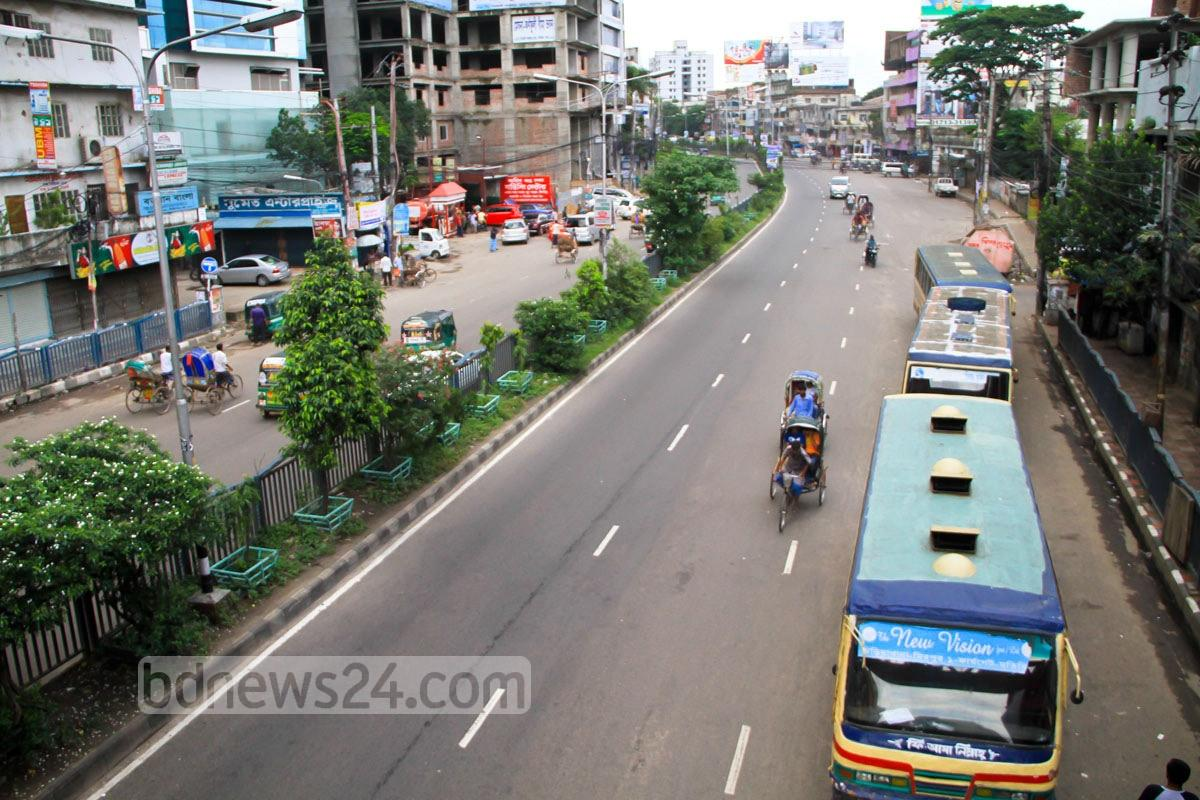

In [13]:
sample_image = Image.open(sample_fn)

sample_image